In [1]:
import numpy as np
import math
from scipy.constants import m_e, c, e, hbar, physical_constants, epsilon_0
from scipy.special import gamma
import tqdm
import numba
import matplotlib.pyplot as plt
import pandas as pd
from ionization_routines import get_fraction_and_temperature_multispecies, process_intensity_array_multispecies, load_intensity_profile

# Temperature from ionization

In [2]:
# Define ionization levels for H and N species
ionization_levels = [
    { 'species_name': 'H', 'initial_charge': 0, 'final_charge': 1, 'Uion_eV': 13.6 },
    { 'species_name': 'N', 'initial_charge': 0, 'final_charge': 1, 'Uion_eV': 14.53 },
    { 'species_name': 'N', 'initial_charge': 1, 'final_charge': 2, 'Uion_eV': 29.60 },
    { 'species_name': 'N', 'initial_charge': 2, 'final_charge': 3, 'Uion_eV': 47.45 },
    { 'species_name': 'N', 'initial_charge': 3, 'final_charge': 4, 'Uion_eV': 77.47 },
    { 'species_name': 'N', 'initial_charge': 4, 'final_charge': 5, 'Uion_eV': 97.89 }
]

# Species keys for population tracking
species_keys = ['H_0', 'H_1', 'N_0', 'N_1', 'N_2', 'N_3', 'N_4', 'N_5']
num_species = len(species_keys)
num_transitions = len(ionization_levels)

In [3]:
# Calculate ADK parameters for all transitions
UH = 13.6 * e
alpha = physical_constants['fine-structure constant'][0]
r_e = physical_constants['classical electron radius'][0]
wa = alpha**3 * c / r_e
Ea = m_e*c**2/e * alpha**4/r_e

# Calculate l_eff for each species based on their ground state. Generalized for future additions like helium
species_l_eff = {}
for transition_dict in ionization_levels:
    species_name = transition_dict['species_name']
    # Only calculate l_eff for ground state (initial_charge = 0)
    if transition_dict['initial_charge'] == 0 and species_name not in species_l_eff:
        ground_state_Uion = transition_dict['Uion_eV'] * e
        ground_state_Z = transition_dict['final_charge']
        ground_state_n_eff = ground_state_Z * np.sqrt(UH/ground_state_Uion)
        species_l_eff[species_name] = ground_state_n_eff - 1

for transition_dict in ionization_levels:
    transition_dict['Uion'] = transition_dict['Uion_eV'] * e
    transition_dict['Z'] = transition_dict['final_charge']
    transition_dict['n_eff'] = transition_dict['Z'] * np.sqrt( UH/transition_dict['Uion'] )
    # Use the l_eff calculated from the ground state of this species
    transition_dict['l_eff'] = species_l_eff[transition_dict['species_name']]
    transition_dict['C2'] = 2**(2*transition_dict['n_eff']) / (transition_dict['n_eff'] * gamma(transition_dict['n_eff']+transition_dict['l_eff']+1) * gamma(transition_dict['n_eff']-transition_dict['l_eff']))
    transition_dict['adk_power'] = -(2*transition_dict['n_eff'] - 1)
    transition_dict['adk_prefactor'] = wa * transition_dict['C2'] * ( transition_dict['Uion']/(2*UH) ) \
        * ( 2*(transition_dict['Uion']/UH)**(3./2)*Ea )**(2*transition_dict['n_eff'] - 1)
    transition_dict['adk_exp_prefactor'] = -2./3 * ( transition_dict['Uion']/UH )**(3./2) * Ea
# Create numba-compatible arrays
adk_prefactors = np.array([d['adk_prefactor'] for d in ionization_levels])
adk_powers = np.array([d['adk_power'] for d in ionization_levels])
adk_exp_prefactors = np.array([d['adk_exp_prefactor'] for d in ionization_levels])

# Create arrays that map each transition to its source and target species index
source_indices = np.zeros(num_transitions, dtype=np.int64)
target_indices = np.zeros(num_transitions, dtype=np.int64)
for i, d in enumerate(ionization_levels):
    source_key = f"{d['species_name']}_{d['initial_charge']}"
    target_key = f"{d['species_name']}_{d['final_charge']}"
    source_indices[i] = species_keys.index(source_key)
    target_indices[i] = species_keys.index(target_key)

charges = np.array([float(key.split('_')[1]) for key in species_keys], dtype=np.float64)


In [4]:
a0 = 0.05
tau = 30e-15 # FWHM duration
lambd = 0.8e-6
ell = np.array([0,1])

default_populations = np.array([0.95, 0.0, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0])

final_pops, T, _ = get_fraction_and_temperature_multispecies(a0, tau, lambd, ell,
                                                            adk_prefactors, adk_powers, adk_exp_prefactors,
                                                            source_indices, target_indices, charges,
                                                            default_populations)
print(f"Final populations: {final_pops}")
print(f"Temperature: {T:.2f} eV")


Final populations: [0.00000000e+000 9.50000000e-001 0.00000000e+000 5.41100695e-320
 2.41694432e-019 4.99236361e-002 7.63639061e-005 3.66818362e-011]
Temperature: 4.11 eV


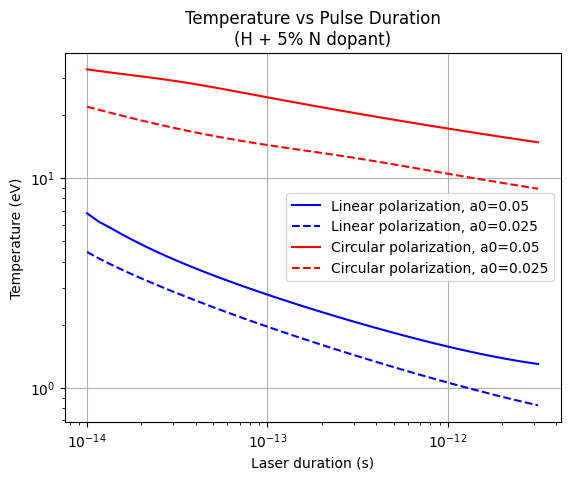

In [5]:
tau_arr = 10**np.linspace(-14, -11.5, 40)
lambd = 0.8e-6

# Define initial populations for multi-species calculation
# 95% H, 5% N (all neutral)
initial_pops = np.array([0.95, 0.0, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0])

# Linear polarization, a0=0.05
a0 = 0.05
ell = np.array([0,1])
T_arr = [ get_fraction_and_temperature_multispecies( a0, tau, lambd, ell,
                                                    adk_prefactors, adk_powers, adk_exp_prefactors,
                                                    source_indices, target_indices, charges,
                                                    initial_pops )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'b-', label='Linear polarization, a0=0.05' )

# Linear polarization, a0=0.025
a0 = 0.025
ell = np.array([0,1])
T_arr = [ get_fraction_and_temperature_multispecies( a0, tau, lambd, ell,
                                                    adk_prefactors, adk_powers, adk_exp_prefactors,
                                                    source_indices, target_indices, charges,
                                                    initial_pops )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'b--', label='Linear polarization, a0=0.025' )

# Circular polarization, a0=0.05
a0 = 0.05
ell = np.array([1,1])/2**.5
T_arr = [ get_fraction_and_temperature_multispecies( a0, tau, lambd, ell,
                                                    adk_prefactors, adk_powers, adk_exp_prefactors,
                                                    source_indices, target_indices, charges,
                                                    initial_pops )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'r-', label='Circular polarization, a0=0.05' )

# Circular polarization, a0=0.025
a0 = 0.025
ell = np.array([1,1])/2**.5
T_arr = [ get_fraction_and_temperature_multispecies( a0, tau, lambd, ell,
                                                    adk_prefactors, adk_powers, adk_exp_prefactors,
                                                    source_indices, target_indices, charges,
                                                    initial_pops )[1] for tau in tau_arr ]
plt.loglog( tau_arr, T_arr, 'r--', label='Circular polarization, a0=0.025' )

plt.grid()
plt.legend(loc=0)
plt.xlabel('Laser duration (s)')
plt.ylabel('Temperature (eV)')
plt.title('Temperature vs Pulse Duration\n(H + 5% N dopant)')
plt.show()


Processing 1D multi-species profile: 100%|██████████| 100/100 [00:00<00:00, 729.24it/s]


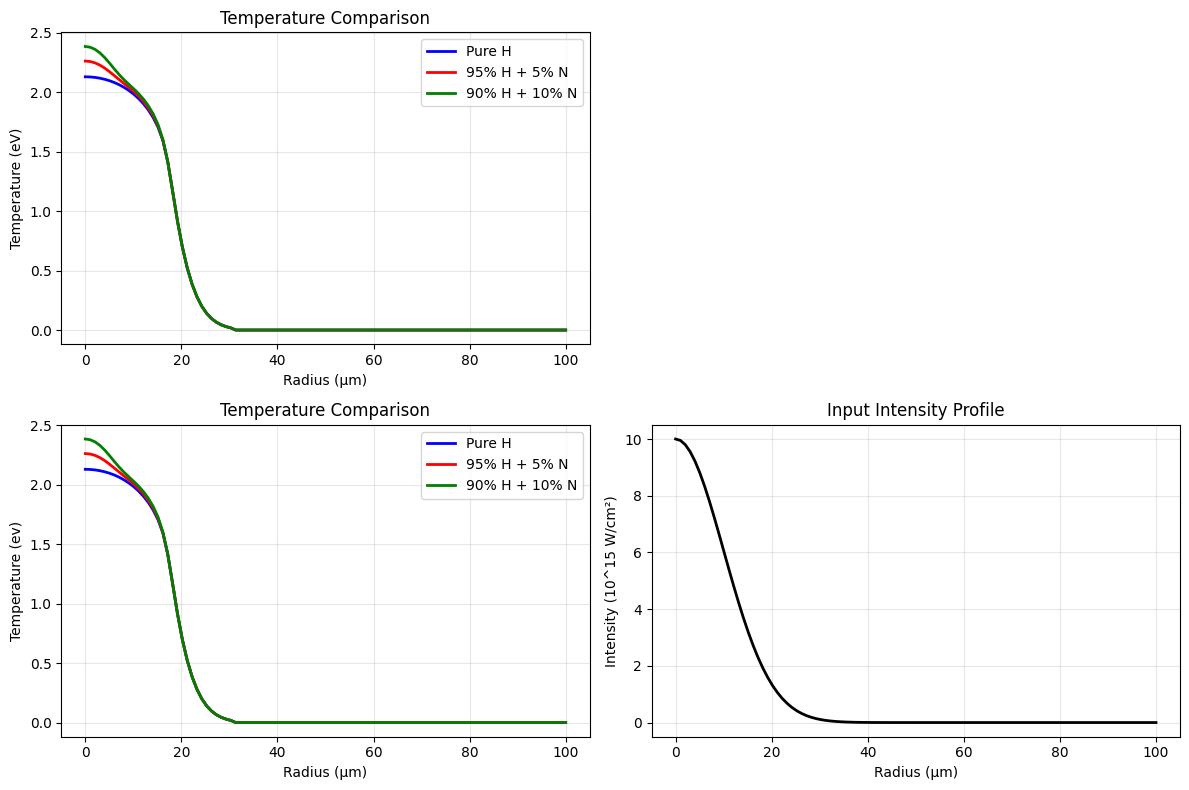

In [6]:
# Parameters
lambd = 0.8e-6
tau = 50e-15
ell = np.array([1, 0])  # linear polarization

# Create 1D radial intensity profile
r_1d = np.linspace(0, 100e-6, 100)
w0_1d = 20e-6  # beam waist
I0_1d = 1e19  # peak intensity in W/m^2
intensity_1d = I0_1d * np.exp(-2*r_1d**2/w0_1d**2)


# Create sample file for demonstration
np.savetxt('sample_intensity_hn.txt', intensity_1d)

# Load intensity profile
intensity_loaded = load_intensity_profile('sample_intensity_hn.txt')

# Compare different dopant concentrations
concentrations = [
    (np.array([1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]), "Pure H", "blue"),
    (np.array([0.95, 0.0, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0]), "95% H + 5% N", "red"),
    (np.array([0.9, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0, 0.0]), "90% H + 10% N", "green")
]

plt.figure(figsize=(12, 8))


plt.subplot(221)
for pops, label, color in concentrations:
    all_pops, T_eV = process_intensity_array_multispecies(intensity_loaded, lambd, tau, ell,
        adk_prefactors, adk_powers, adk_exp_prefactors, source_indices, target_indices, charges, pops)
    plt.plot(r_1d*1e6, T_eV, color=color, linewidth=2, label=label)

plt.xlabel('Radius (μm)')
plt.ylabel('Temperature (eV)')
plt.title('Temperature Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot temperature in log scale
plt.subplot(223)
for pops, label, color in concentrations:
    all_pops, T_eV = process_intensity_array_multispecies(intensity_loaded, lambd, tau, ell,
        adk_prefactors, adk_powers, adk_exp_prefactors, source_indices, target_indices, charges, pops)
    plt.plot(r_1d*1e6, T_eV, color=color, linewidth=2, label=label)

plt.xlabel('Radius (μm)')
plt.ylabel('Temperature (ev)')
plt.title('Temperature Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot intensity profile for reference
plt.subplot(224)
plt.plot(r_1d*1e6, intensity_loaded/1000 * 1e-15, 'k-', linewidth=2)
plt.xlabel('Radius (μm)')
plt.ylabel('Intensity (10^15 W/cm²)')
plt.title('Input Intensity Profile')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Clean up
import os
os.remove('sample_intensity_hn.txt')


# Ionization volume for a focusing pulse

In [7]:
a0 = 0.05
w0 = 5.e-6
lambd = 0.8e-6
tau = 1.5e-12 # FWHM duration
ell = np.array([0,1])

zr = np.pi*w0**2/lambd

In [ ]:
zmax = 400e-6
rmax = 50e-6
r, z = np.meshgrid( np.linspace(-rmax, rmax, 100), np.linspace(-zmax, zmax, 100), indexing='ij' )
a = a0/np.sqrt(1 + z**2/zr**2)*np.exp( -r**2/w0**2/(1+z**2/zr**2) )

# Initialize arrays for average charge state and temperature
n = np.zeros_like( a )  # Will store average charge state <Z>
T = np.zeros_like( a )  # Will store temperature

# Process each point in the 2D grid
for i in tqdm.tqdm( range(n.shape[0]) ):
    for j in range(n.shape[1]):
        final_pops, T0, _ = get_fraction_and_temperature_multispecies(
            a[i,j], tau, lambd, ell,
            adk_prefactors, adk_powers, adk_exp_prefactors,
            source_indices, target_indices, charges,
            initial_pops
        )
        # Calculate average charge state
        n[i,j] = float(np.sum(charges * final_pops))
        T[i,j] = T0

  5%|▌         | 5/100 [00:19<06:10,  3.90s/it]

In [ ]:
plt.figure(figsize=(5,8))

extent = 1.e6*np.array([-zmax, zmax, -rmax, rmax])

plt.subplot(311)
plt.imshow(a, extent=extent, aspect='auto', cmap='gist_heat_r')
cb = plt.colorbar()
cb.set_label('a (laser)')
plt.ylabel('r (microns)')

plt.subplot(312)
plt.imshow(2e18*n, extent=extent, aspect='auto', cmap='gist_heat_r', vmax=2.5e18)
cb = plt.colorbar()
cb.set_label('$n_e\;(cm^{-2})$')
plt.ylabel('r (microns)')

plt.subplot(313)
plt.imshow(T, extent=extent, aspect='auto', cmap='gist_heat_r', vmax=20)
cb = plt.colorbar()
cb.set_label('T (eV)')
plt.ylabel('r (microns)')

In [ ]:
#example of writing and reading gaussian laser intensity from file and plotting 1d temperature

lambd = 0.8e-6
tau = 50e-15 # FWHM duration
ell = np.array([1, 0])  # linear polarization

# Example: 1D radial intensity profile (cylindrical symmetry)
print("Example 1: 1D radial profile")
r_1d = np.linspace(0, 100e-6, 100)  # radial coordinate from 0 to 100 microns
w0_1d = 20e-6  # beam waist
I0_1d = 1e19  # peak intensity in W/m^2
intensity_1d = I0_1d * np.exp(-2*r_1d**2/w0_1d**2)

sample_1d_data = intensity_1d
np.savetxt('sample_radial_intensity.txt', sample_1d_data)
np.savetxt('sample_radial_intensity.csv', sample_1d_data, delimiter=',')

# Load from files
intensity_from_txt = load_intensity_profile('sample_radial_intensity.txt')
intensity_from_csv = load_intensity_profile('sample_radial_intensity.csv')

print(f"Loaded 1D profile shape: {intensity_from_txt.shape}")
print(f"Data match: {np.allclose(intensity_from_txt, intensity_from_csv)}")
pops = np.array([0.95, 0.0, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0])
# Process the loaded 1D data
ioniz_frac_file, T_eV_file = process_intensity_array_multispecies(intensity_from_txt, lambd, tau, ell, pops,
    adk_prefactors, adk_powers, adk_exp_prefactors, source_indices, target_indices, charges,
    output_file='plasma_from_file.csv', r_coords=r_1d)

plt.figure(figsize=(6, 6))

plt.plot(r_1d*1e6, T_eV_file, 'b-', linewidth=2, label='Original 1D')
plt.xlabel('Radius (μm)')
plt.ylabel('Temperature (eV)')
plt.title('1D Temperature Profile\n(from file)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Clean up sample files
import os
os.remove('sample_radial_intensity.txt')
os.remove('sample_radial_intensity.csv')